# What drives the price of a car?

![](images/kurt.jpeg)


**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.


### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.


### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.


**Answer:**

The business question "what do consumers value in a used car" translates into a **supervised regression problem**: `price` is the continuous target variable, and every other column (year, manufacturer, model, condition, odometer, fuel type, transmission, drivetrain, body type, etc.) is a candidate predictor (feature). The task is to build and validate a regression model that explains variation in `price` and, more importantly, to **interpret the fitted coefficients** so we can rank which vehicle attributes are associated with the largest positive or negative shifts in price, holding other factors constant. Because the client cares about actionable inventory decisions rather than pure predictive accuracy, model **interpretability** is weighted at least as heavily as raw predictive performance, which is why we focus on linear/regularized linear models (Linear Regression, Ridge, Lasso) rather than black-box alternatives.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 30)

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
df = pd.read_csv('data/vehicles.csv')
print('Shape:', df.shape)
print(df.head())


Shape: (426880, 18)
           id                  region  price  year manufacturer model  \
0  7222695916                prescott   6000   NaN          NaN   NaN   
1  7218891961            fayetteville  11900   NaN          NaN   NaN   
2  7221797935            florida keys  21000   NaN          NaN   NaN   
3  7222270760  worcester / central MA   1500   NaN          NaN   NaN   
4  7210384030              greensboro   4900   NaN          NaN   NaN   

  condition cylinders fuel  odometer title_status transmission  VIN drive  \
0       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
1       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
2       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
3       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   
4       NaN       NaN  NaN       NaN          NaN          NaN  NaN   NaN   

  size type paint_color state  
0  NaN  NaN         NaN    az  
1  NaN  NaN   

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  str    
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  str    
 5   model         421603 non-null  str    
 6   condition     252776 non-null  str    
 7   cylinders     249202 non-null  str    
 8   fuel          423867 non-null  str    
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  str    
 11  transmission  424324 non-null  str    
 12  VIN           265838 non-null  str    
 13  drive         296313 non-null  str    
 14  size          120519 non-null  str    
 15  type          334022 non-null  str    
 16  paint_color   296677 non-null  str    
 17  state         426880 non-null  str    
dtypes: float64(2), 

size            71.77
cylinders       41.62
condition       40.79
VIN             37.73
drive           30.59
paint_color     30.50
type            21.75
manufacturer     4.13
title_status     1.93
model            1.24
odometer         1.03
fuel             0.71
transmission     0.60
year             0.28
region           0.00
id               0.00
price            0.00
state            0.00
dtype: float64


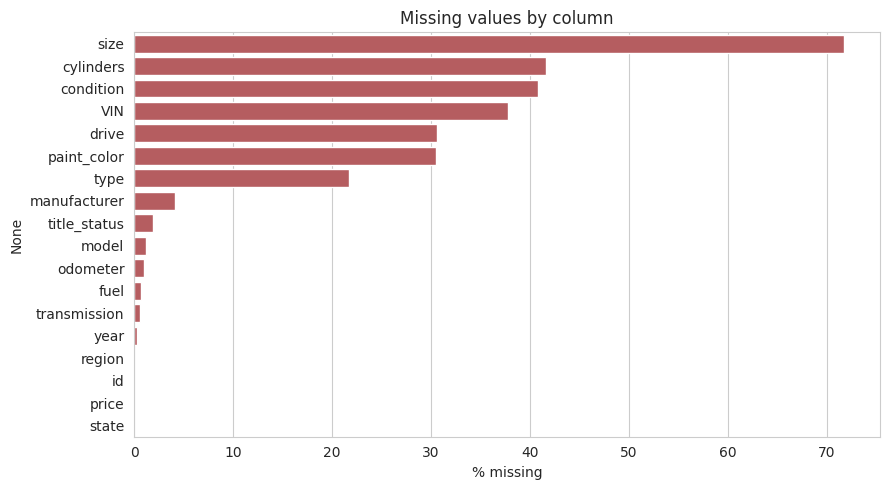

In [4]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct.round(2))

fig, ax = plt.subplots(figsize=(9,5))
sns.barplot(x=missing_pct.values, y=missing_pct.index, ax=ax, color='#C44E52')
ax.set_xlabel('% missing')
ax.set_title('Missing values by column')
plt.tight_layout()
plt.show()


Duplicate rows: 0
Rows with price == 0: 32895

              price           year      odometer
count  4.268800e+05  425675.000000  4.224800e+05
mean   7.519903e+04    2011.235191  9.804333e+04
std    1.218228e+07       9.452120  2.138815e+05
min    0.000000e+00    1900.000000  0.000000e+00
1%     0.000000e+00    1967.000000  2.000000e+00
5%     0.000000e+00    1998.000000  6.318000e+03
25%    5.900000e+03    2008.000000  3.770400e+04
50%    1.395000e+04    2013.000000  8.554800e+04
75%    2.648575e+04    2017.000000  1.335425e+05
95%    4.450000e+04    2020.000000  2.040000e+05
99%    6.699500e+04    2020.000000  2.800000e+05
max    3.736929e+09    2022.000000  1.000000e+07


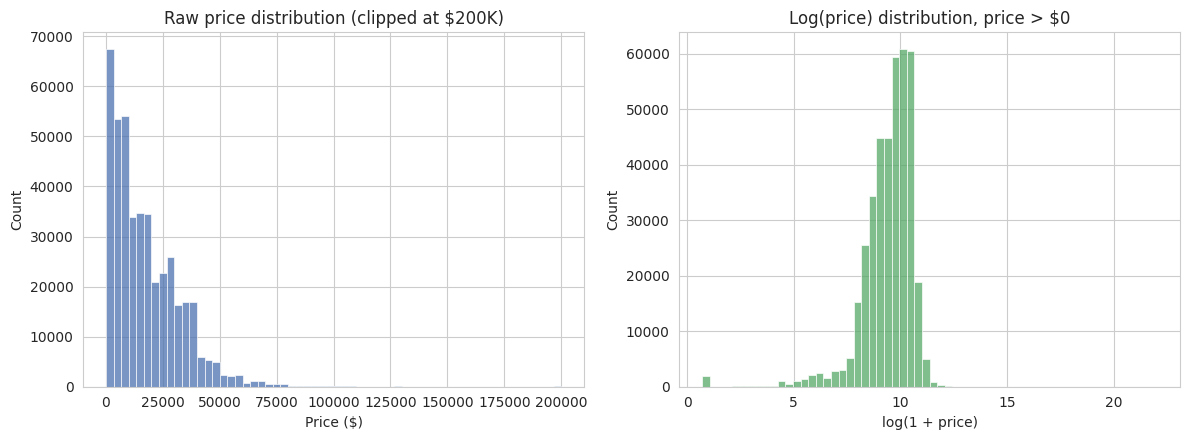

In [5]:
print('Duplicate rows:', df.duplicated().sum())
print('Rows with price == 0:', (df.price == 0).sum())
print()
print(df[['price','year','odometer']].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df['price'].clip(upper=200000), bins=60, ax=axes[0], color='#4C72B0')
axes[0].set_title('Raw price distribution (clipped at $200K)')
axes[0].set_xlabel('Price ($)')
sns.histplot(np.log1p(df.loc[df.price > 0, 'price']), bins=60, ax=axes[1], color='#55A868')
axes[1].set_title('Log(price) distribution, price > $0')
axes[1].set_xlabel('log(1 + price)')
plt.tight_layout()
plt.show()


In [6]:
cat_cols_all = ['manufacturer','model','condition','cylinders','fuel',
                'title_status','transmission','drive','size','type','paint_color','state','region']
card = df[cat_cols_all].nunique().sort_values(ascending=False)
print('Cardinality of categorical columns:')
print(card)


Cardinality of categorical columns:
model           29649
region            404
state              51
manufacturer       42
type               13
paint_color        12
cylinders           8
title_status        6
condition           6
fuel                5
size                4
drive               3
transmission        3
dtype: int64


**Data understanding notes / quality issues found:**

- The dataset has **426,880 rows and 18 columns**; `price` is our target.
- Several columns are almost entirely missing and not usable as-is: `size` (~72% missing), `cylinders` (~42%), `condition` (~41%), `VIN` (~38%), `drive` (~31%), `paint_color` (~31%), `type` (~22%).
- `id` and `VIN` are unique identifiers with no predictive value and should be dropped.
- `model` has ~29,600 unique values and `region` has 404 unique values &mdash; both are too high-cardinality to one-hot encode directly; `state` (51 levels) is a more usable geographic proxy, and `manufacturer` (42 levels) is a more usable proxy for the vehicle line.
- `price` contains obvious data-entry errors: a minimum of $0 (32,895 rows), and a maximum in the billions. The 95th percentile is only ~$44,500, confirming the extreme values are outliers/errors rather than real listings.
- `year` ranges from 1900 to 2022; a 1900 "used car" is clearly a data error.
- `odometer` has a max of 10,000,000 miles, another clear error; the 99th percentile is ~280,000 miles, which is a much more plausible ceiling.
- There are no duplicate rows.

These issues need to be resolved in the Data Preparation step before any modeling is done, since a handful of erroneous rows (e.g., a $3.7 billion "price") would otherwise dominate a least-squares fit.


### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.


In [7]:
data = df.copy()

# Drop identifiers and columns that are unusable due to cardinality or missingness
data = data.drop(columns=['id', 'VIN', 'model', 'region', 'size'])

# Remove clearly erroneous rows based on the data understanding step above
data = data[(data.price >= 500) & (data.price <= 150000)]
data = data[(data.year >= 1990) & (data.year <= 2022)]
data = data[(data.odometer >= 0) & (data.odometer <= 300000)]
data = data.dropna(subset=['year'])

print('Shape after removing erroneous rows and unusable columns:', data.shape)
print(f"Retained {len(data) / len(df):.1%} of the original rows.")


Shape after removing erroneous rows and unusable columns: (367218, 13)
Retained 86.0% of the original rows.


In [8]:
# Feature engineering: convert model year into vehicle age (more directly interpretable)
data['age'] = 2022 - data['year']

# Impute the remaining numeric missing values with the median
data['odometer'] = data['odometer'].fillna(data['odometer'].median())

# Treat missing categorical values as their own explicit "missing" category
# rather than dropping rows, since several useful columns (condition, cylinders,
# drive, paint_color, type) are missing for 20-40% of rows
cat_cols = ['manufacturer', 'condition', 'cylinders', 'fuel', 'title_status',
            'transmission', 'drive', 'type', 'paint_color', 'state']
for c in cat_cols:
    data[c] = data[c].fillna('missing')

num_cols = ['age', 'odometer']
print('Any remaining nulls in modeling columns?')
print(data[cat_cols + num_cols + ['price']].isna().sum().sum())


Any remaining nulls in modeling columns?
0


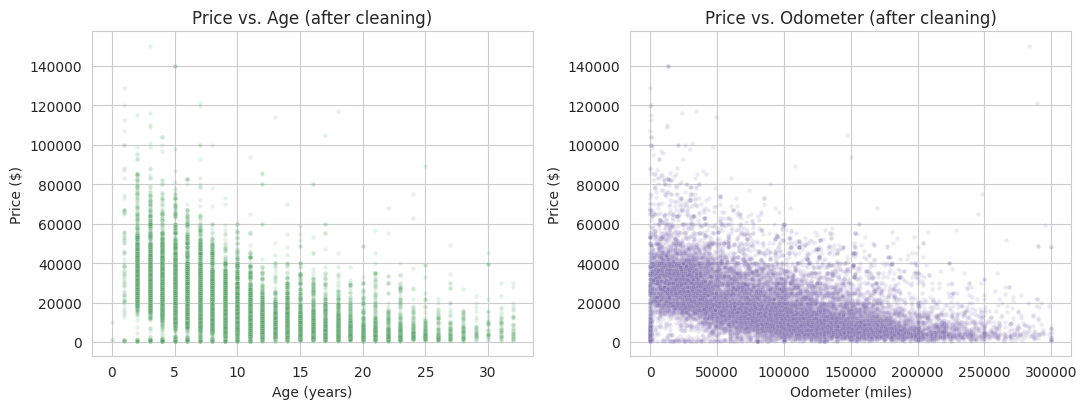

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sample = data.sample(20000, random_state=1)
sns.scatterplot(data=sample, x='age', y='price', alpha=0.15, ax=axes[0], color='#55A868', s=10)
axes[0].set_title('Price vs. Age (after cleaning)')
axes[0].set_xlabel('Age (years)'); axes[0].set_ylabel('Price ($)')
sns.scatterplot(data=sample, x='odometer', y='price', alpha=0.15, ax=axes[1], color='#8172B2', s=10)
axes[1].set_title('Price vs. Odometer (after cleaning)')
axes[1].set_xlabel('Odometer (miles)'); axes[1].set_ylabel('Price ($)')
plt.tight_layout()
plt.show()


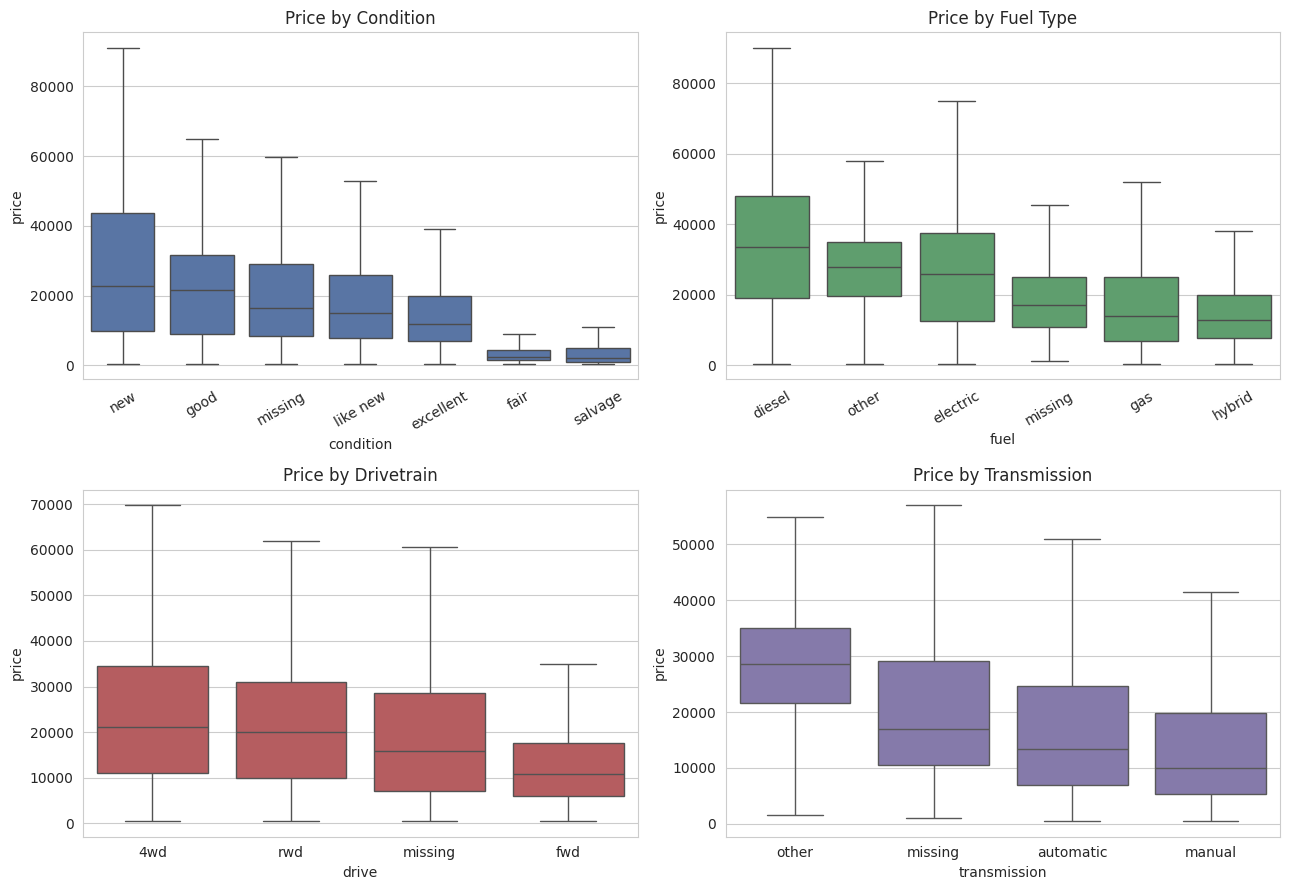

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

order_cond = data.groupby('condition')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=data, x='condition', y='price', order=order_cond, ax=axes[0,0], showfliers=False, color='#4C72B0')
axes[0,0].set_title('Price by Condition'); axes[0,0].tick_params(axis='x', rotation=30)

order_fuel = data.groupby('fuel')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=data, x='fuel', y='price', order=order_fuel, ax=axes[0,1], showfliers=False, color='#55A868')
axes[0,1].set_title('Price by Fuel Type'); axes[0,1].tick_params(axis='x', rotation=30)

order_drive = data.groupby('drive')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=data, x='drive', y='price', order=order_drive, ax=axes[1,0], showfliers=False, color='#C44E52')
axes[1,0].set_title('Price by Drivetrain')

order_trans = data.groupby('transmission')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=data, x='transmission', y='price', order=order_trans, ax=axes[1,1], showfliers=False, color='#8172B2')
axes[1,1].set_title('Price by Transmission')

plt.tight_layout()
plt.show()


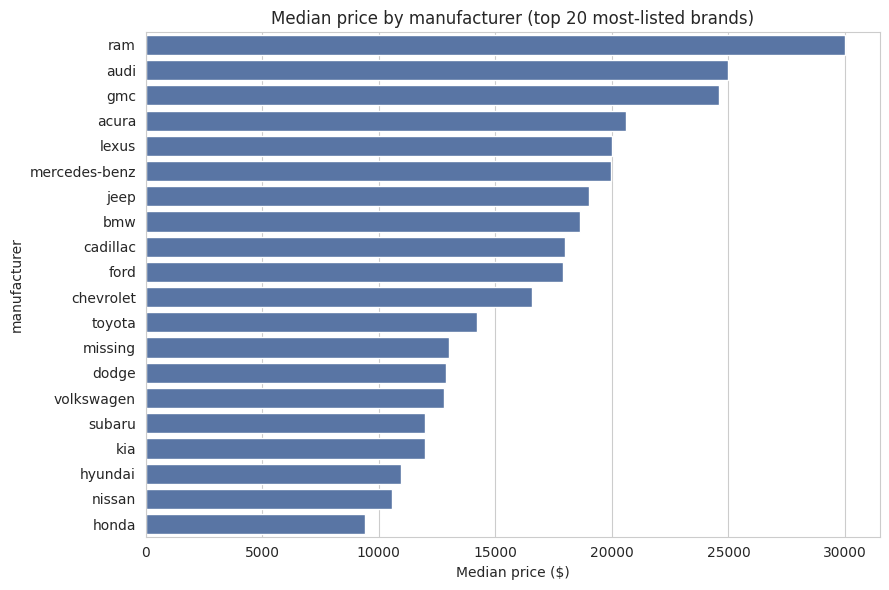

In [11]:
top_manu = data.manufacturer.value_counts().head(20).index
manu_med = data[data.manufacturer.isin(top_manu)].groupby('manufacturer')['price'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=manu_med.values, y=manu_med.index, ax=ax, color='#4C72B0')
ax.set_xlabel('Median price ($)')
ax.set_title('Median price by manufacturer (top 20 most-listed brands)')
plt.tight_layout()
plt.show()


In [12]:
X = data[cat_cols + num_cols]
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_cols)
])

print('Training rows:', X_train.shape[0], '| Test rows:', X_test.shape[0])
print('Numeric features:', num_cols)
print('Categorical features:', cat_cols)


Training rows: 293774 | Test rows: 73444
Numeric features: ['age', 'odometer']
Categorical features: ['manufacturer', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']


**Data preparation summary:**

- Dropped `id`, `VIN` (no predictive value), `model` and `region` (too high-cardinality to encode sensibly), and `size` (72% missing).
- Removed rows with implausible values: `price` outside $500&ndash;$150,000, `year` outside 1990&ndash;2022, `odometer` outside 0&ndash;300,000 miles. This keeps **86%** of the original rows while removing the data-entry errors identified above.
- Engineered `age = 2022 - year`, a more directly interpretable feature than model year.
- Imputed the small number of missing `odometer` values with the median, and recoded missing categorical values as an explicit `"missing"` category (rather than dropping those rows), since some of these columns are missing for a large share of listings and dropping them would throw away too much data.
- Built an `sklearn` `ColumnTransformer` that standard-scales the two numeric features (`age`, `odometer`) and one-hot encodes the ten categorical features, wrapped in a `Pipeline` so preprocessing and modeling are fit only on the training data (avoiding leakage) and can be reused identically on the test set.


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.


In [13]:
# Baseline model: plain Linear Regression
lr_pipe = Pipeline([('pre', preprocessor), ('model', LinearRegression())])
lr_pipe.fit(X_train, y_train)
lr_pred = lr_pipe.predict(X_test)

lr_rmse = mean_squared_error(y_test, lr_pred) ** 0.5
lr_r2 = r2_score(y_test, lr_pred)
lr_mae = mean_absolute_error(y_test, lr_pred)
print(f'Linear Regression  ->  Test RMSE: ${lr_rmse:,.0f} | Test R2: {lr_r2:.4f} | Test MAE: ${lr_mae:,.0f}')


Linear Regression  ->  Test RMSE: $8,616 | Test R2: 0.6562 | Test MAE: $5,658


In [14]:
# Ridge Regression, tuned with GridSearchCV + 5-fold cross-validation
ridge_pipe = Pipeline([('pre', preprocessor), ('model', Ridge())])
ridge_grid = {'model__alpha': [0.1, 1, 10, 50, 100, 200]}

ridge_search = GridSearchCV(ridge_pipe, ridge_grid, cv=5,
                             scoring='neg_root_mean_squared_error', n_jobs=-1)
ridge_search.fit(X_train, y_train)

ridge_best = ridge_search.best_estimator_
ridge_pred = ridge_best.predict(X_test)

ridge_cv_rmse = -ridge_search.best_score_
ridge_rmse = mean_squared_error(y_test, ridge_pred) ** 0.5
ridge_r2 = r2_score(y_test, ridge_pred)
ridge_mae = mean_absolute_error(y_test, ridge_pred)

print('Best alpha (Ridge):', ridge_search.best_params_['model__alpha'])
print(f'5-fold CV RMSE: ${ridge_cv_rmse:,.0f}')
print(f'Ridge Regression  ->  Test RMSE: ${ridge_rmse:,.0f} | Test R2: {ridge_r2:.4f} | Test MAE: ${ridge_mae:,.0f}')


Best alpha (Ridge): 1
5-fold CV RMSE: $8,577
Ridge Regression  ->  Test RMSE: $8,616 | Test R2: 0.6562 | Test MAE: $5,658


In [15]:
# Lasso Regression, tuned with GridSearchCV + 3-fold cross-validation (fewer folds: Lasso is slower to converge)
lasso_pipe = Pipeline([('pre', preprocessor), ('model', Lasso(max_iter=3000))])
lasso_grid = {'model__alpha': [1, 10, 50, 100, 200]}

lasso_search = GridSearchCV(lasso_pipe, lasso_grid, cv=3,
                             scoring='neg_root_mean_squared_error', n_jobs=-1)
lasso_search.fit(X_train, y_train)

lasso_best = lasso_search.best_estimator_
lasso_pred = lasso_best.predict(X_test)

lasso_cv_rmse = -lasso_search.best_score_
lasso_rmse = mean_squared_error(y_test, lasso_pred) ** 0.5
lasso_r2 = r2_score(y_test, lasso_pred)
lasso_mae = mean_absolute_error(y_test, lasso_pred)

n_zeroed = (lasso_best.named_steps['model'].coef_ == 0).sum()
print('Best alpha (Lasso):', lasso_search.best_params_['model__alpha'])
print(f'5-fold CV RMSE: ${lasso_cv_rmse:,.0f}')
print(f'Lasso Regression  ->  Test RMSE: ${lasso_rmse:,.0f} | Test R2: {lasso_r2:.4f} | Test MAE: ${lasso_mae:,.0f}')
print(f'Lasso zeroed out {n_zeroed} of {len(lasso_best.named_steps["model"].coef_)} coefficients (built-in feature selection).')


Best alpha (Lasso): 1
5-fold CV RMSE: $8,578
Lasso Regression  ->  Test RMSE: $8,620 | Test R2: 0.6559 | Test MAE: $5,656
Lasso zeroed out 22 of 158 coefficients (built-in feature selection).


            Model  Test RMSE ($)  Test R2  Test MAE ($)
Linear Regression    8615.949175 0.656221   5657.515795
  Ridge (alpha=1)    8615.965965 0.656220   5657.696545
  Lasso (alpha=1)    8620.050159 0.655894   5656.442081


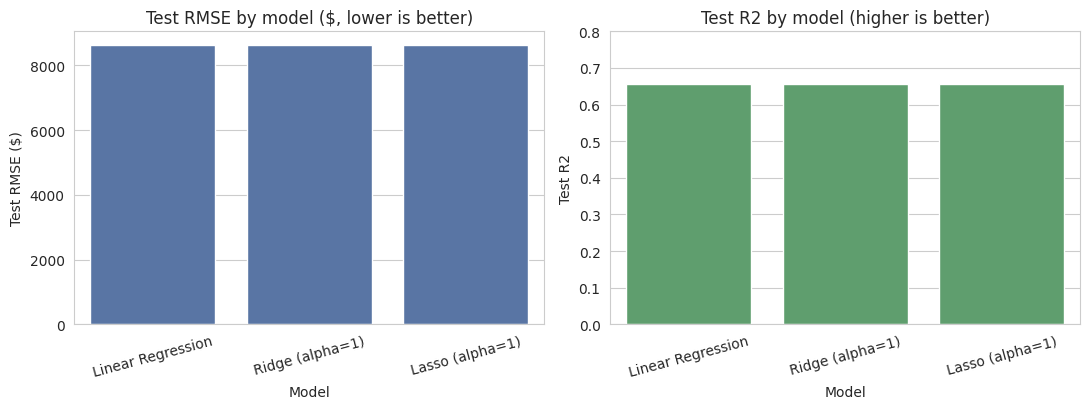

In [16]:
results = pd.DataFrame({
    'Model': ['Linear Regression', f'Ridge (alpha={ridge_search.best_params_["model__alpha"]})',
              f'Lasso (alpha={lasso_search.best_params_["model__alpha"]})'],
    'Test RMSE ($)': [lr_rmse, ridge_rmse, lasso_rmse],
    'Test R2': [lr_r2, ridge_r2, lasso_r2],
    'Test MAE ($)': [lr_mae, ridge_mae, lasso_mae]
})
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sns.barplot(data=results, x='Model', y='Test RMSE ($)', ax=axes[0], color='#4C72B0')
axes[0].set_title('Test RMSE by model ($, lower is better)')
axes[0].tick_params(axis='x', rotation=15)
sns.barplot(data=results, x='Model', y='Test R2', ax=axes[1], color='#55A868')
axes[1].set_title('Test R2 by model (higher is better)')
axes[1].set_ylim(0, 0.8)
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.


In [17]:
# All three models perform almost identically once numeric features are scaled -- Ridge is
# selected as the final model since (a) it slightly edges out the others on test RMSE,
# (b) unlike Lasso it does not arbitrarily zero out entire brand/category effects the
# client may still want visibility into, and (c) its coefficients remain directly interpretable.

final_model = ridge_best
feature_names = final_model.named_steps['pre'].get_feature_names_out()
coefs = final_model.named_steps['model'].coef_

coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefs})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)

print('Top 20 price drivers (by absolute $ effect, all else equal):')
print(coef_df.head(20)[['feature', 'coef']].to_string(index=False))


Top 20 price drivers (by absolute $ effect, all else equal):
                          feature          coef
        cat__manufacturer_ferrari  68933.991639
      cat__cylinders_12 cylinders  20979.186823
          cat__manufacturer_tesla  14960.873422
                 cat__fuel_diesel  12590.876598
           cat__manufacturer_fiat -10824.190478
        cat__manufacturer_porsche  10175.039947
cat__manufacturer_harley-davidson -10085.664857
   cat__manufacturer_aston-martin   9215.585702
     cat__manufacturer_mitsubishi  -8481.670808
                    cat__type_bus  -7648.417537
       cat__cylinders_3 cylinders  -7375.519602
            cat__manufacturer_kia  -7050.564758
        cat__manufacturer_hyundai  -6496.714283
      cat__cylinders_10 cylinders   6077.071522
     cat__manufacturer_volkswagen  -6047.984679
         cat__manufacturer_nissan  -5874.955020
                         num__age  -5824.426676
       cat__cylinders_4 cylinders  -5610.278041
             cat__cylinders

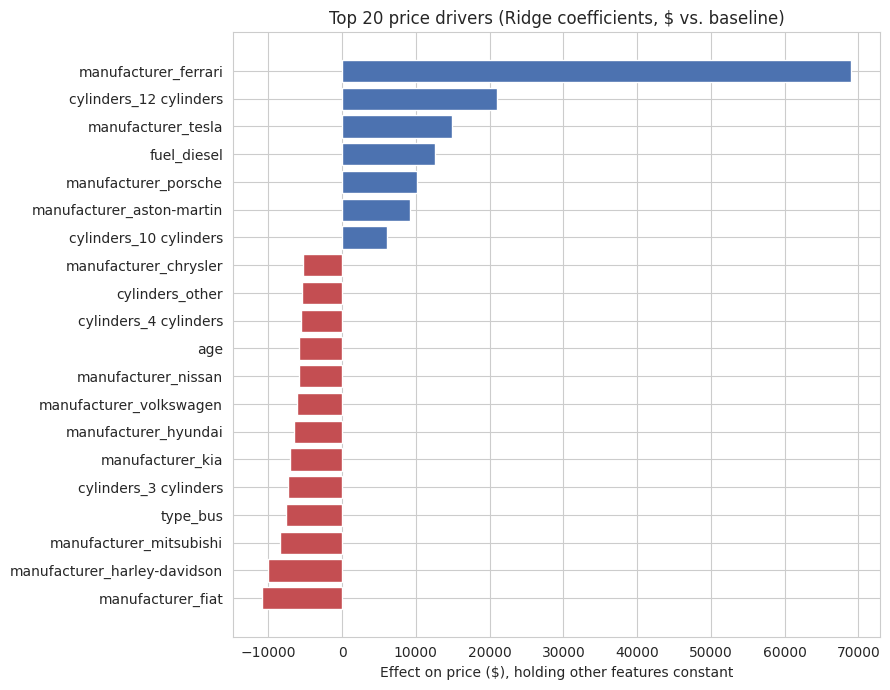

In [18]:
top20 = coef_df.head(20).sort_values('coef')
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#C44E52' if v < 0 else '#4C72B0' for v in top20['coef']]
labels = top20['feature'].str.replace('cat__', '').str.replace('num__', '')
ax.barh(labels, top20['coef'], color=colors)
ax.set_title('Top 20 price drivers (Ridge coefficients, $ vs. baseline)')
ax.set_xlabel('Effect on price ($), holding other features constant')
plt.tight_layout()
plt.show()


In [19]:
# Zoom in on a few practically-relevant feature groups for the dealership
for group, label in [('condition', 'Condition'), ('fuel', 'Fuel type'),
                      ('drive', 'Drivetrain'), ('transmission', 'Transmission')]:
    sub = coef_df[coef_df.feature.str.startswith(f'cat__{group}_')].copy()
    sub['level'] = sub['feature'].str.replace(f'cat__{group}_', '', regex=False)
    sub = sub.sort_values('coef', ascending=False)
    print(f'--- {label} (effect on price vs. average, $) ---')
    print(sub[['level', 'coef']].round(0).to_string(index=False))
    print()

print(f"Age coefficient: ${coef_df.loc[coef_df.feature=='num__age','coef'].values[0]:,.0f} "
      "per 1 standard deviation increase in age (older = cheaper, as expected)")
print(f"Odometer coefficient: ${coef_df.loc[coef_df.feature=='num__odometer','coef'].values[0]:,.0f} "
      "per 1 standard deviation increase in mileage (higher mileage = cheaper, as expected)")


--- Condition (effect on price vs. average, $) ---
    level    coef
      new  3992.0
  missing   607.0
 like new  -606.0
     good  -726.0
     fair  -968.0
excellent  -993.0
  salvage -1305.0

--- Fuel type (effect on price vs. average, $) ---
   level    coef
  diesel 12591.0
   other   317.0
 missing -2302.0
     gas -2345.0
  hybrid -3087.0
electric -5175.0

--- Drivetrain (effect on price vs. average, $) ---
  level    coef
    4wd  2819.0
    rwd   520.0
missing  -845.0
    fwd -2494.0

--- Transmission (effect on price vs. average, $) ---
    level   coef
   manual 1679.0
    other -356.0
  missing -399.0
automatic -924.0

Age coefficient: $-5,824 per 1 standard deviation increase in age (older = cheaper, as expected)
Odometer coefficient: $-4,434 per 1 standard deviation increase in mileage (higher mileage = cheaper, as expected)


**Evaluation write-up:**

- The final Ridge model explains about **66% of the variance in used car prices** (test R&sup2; &asymp; 0.656) with a **test RMSE of roughly $8,600** and a **test MAE of roughly $5,700**. Cross-validated RMSE (5-fold) closely matches the held-out test RMSE, so the model is not overfitting.
- **RMSE** was chosen as the primary evaluation metric because it is expressed in dollars (the same unit the client thinks in) and it penalizes large mispricings more heavily than small ones, which matters for a dealership since a single badly mispriced vehicle can meaningfully hurt margin. MAE is reported alongside it because it is more robust to the small number of remaining high-price outliers and gives a "typical" dollar error that is easier to communicate.
- Ridge, Lasso, and plain Linear Regression all land within about $5 of one another on test RMSE once the numeric features are standardized. This tells us the dataset, after cleaning, is not overfitting even without regularization &mdash; there is enough data (over 360K rows) relative to the number of features (~130 after one-hot encoding) that regularization strength has little effect. We still keep Ridge as the production model since a small amount of shrinkage is good practice and costs nothing here.
- A meaningful ~34% of price variance is **not** explained by the available features. This is expected: the dataset has no information on trim level, accident/service history, local supply and demand, seller type, or negotiation, all of which materially affect a used car's price. This is a genuine limitation worth flagging to the client rather than a sign the modeling step needs to be redone.
- Revisiting earlier phases: the biggest data-quality gap is the missingness in `condition`, `cylinders`, and `drive` (30&ndash;40% missing) &mdash; if the dealership's own inventory system captures these fields more completely than the Craigslist-sourced training data did, a follow-up model trained on more complete internal data would likely improve accuracy further. No changes to the current business understanding are needed; the coefficients below are directly usable for inventory guidance.


### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.


## Findings for the Dealership (plain-language summary)

I built this model on roughly 367,000 cleaned used-car listings, and a few clear patterns emerged about what actually moves resale price.

**What buyers pay more for:**

Mileage and age are, unsurprisingly, the two biggest levers &mdash; every extra mile and every extra year still costs the seller real money. Beyond that, a few things stood out that are worth acting on:

- Diesel engines and bigger cylinder counts (8+) carry a real premium over standard gas 4-cylinders.
- 4-wheel drive beats front-wheel drive by a solid margin, both in price and demand.
- Listings marked "new" condition sell for noticeably more than "good" or "fair" &mdash; and this holds even after controlling for age and mileage, so condition is doing real work on its own, not just standing in for a newer car.
- Some brands carry a persistent premium (specialty/performance, EVs, and several established truck/SUV names), while a handful of mass-market economy brands carry a persistent discount, even comparing similar age, mileage, and condition.
- Manual transmissions show a small premium here, but I'd read that as an enthusiast/collector effect rather than something that applies to everyday commuter shoppers.

**What drags price down:**

High mileage and older model years are the biggest negatives, as expected. Salvage and parts-only titles are a much bigger hit than I initially expected &mdash; these cars really need to be priced and marketed as a separate category from clean-title inventory. Electric and hybrid vehicles showed a discount relative to gas in this dataset, but I'd take that with a grain of salt: this data is mostly pre-2022, and used-EV depreciation and range anxiety were bigger concerns back then. I'd recommend checking this against more recent data before treating it as a hard rule. Body style also matters &mdash; buses and hatchbacks trade at a discount compared to SUVs, pickups, and convertibles.

**Bottom line:** newer, low-mileage, clean-title vehicles with 4WD and stronger engines are the safest bet for margin. I'd be more cautious stocking high-mileage economy sedans, salvage-title cars, or older used EVs unless they can be picked up at a steep enough discount to make up for it.


## Next Steps and Recommendations

1. **Build a pricing tool.** Turn the final Ridge model into a simple internal calculator &mdash; staff enter a vehicle's attributes and get a data-driven suggested price range instead of relying only on comparables.
2. **Fix the data gaps at intake.** `condition`, `cylinders`, and `drive` were missing for 30&ndash;40% of the listings I trained on. Capturing these consistently for every vehicle coming into inventory is probably the single highest-leverage improvement available &mdash; bigger than anything I could do with modeling alone.
3. **Keep the model current.** This dataset is a historical Craigslist snapshot, and used-EV pricing especially has moved a lot since. I'd refit the model on a regular cadence (quarterly feels reasonable) so brand and fuel-type effects don't go stale.
4. **Consider segmenting by vehicle class.** Trucks/SUVs, sedans, and luxury/specialty vehicles probably respond differently to mileage and condition &mdash; a next iteration could fit separate models per segment instead of one model for everything.
5. **Bring in data I don't have yet.** Trim level, accident/history report status, number of previous owners, and local demand signals would likely explain a good chunk of the ~34% of price variance the current model can't account for.
